**Synaptic biophysics** practical course Simulating Synapses day 4

Simulation of fast and slow synaptic currents in a LIF neuron.

Poisson or bursty input trains that undergo short-term plasticity (Tsodyks-Markram model)

Based on the simulation from Neuromatch (Richard Naud): https://instructor.compneuro.neuromatch.io/tutorials/W2D3_BiologicalNeuronModels/instructor/W2D3_Tutorial3.html


In [3]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

Plotting Functions

In [4]:
# show the timing / density of the input trains
def my_illus_trains(pars, train1, train2, show=False):
  """
  Illustration of the spike train

  Args:
    pars  : parameters dictionary
    train1 : spike train
    train2 : spike train

  Returns:
    nothing
  """
  
  plt.subplot(3,2,3)

  #from GPT5

  #eventplot takes a list of spike indices for each train. Multiply by dt to convert to spike times
  positions1 = [list(np.nonzero(row)[0]*pars['dt']) for row in train1]
  positions2 = [list(np.nonzero(row)[0]*pars['dt']) for row in train2]
    
  plt.eventplot(positions1, color='g', lineoffsets = 1)
  plt.eventplot(positions2, color='r', lineoffsets = -1)
    
  plt.xlabel('Time (ms)')
  plt.ylabel('Inputs (green E, red I)')
  #plt.legend(loc=[.8, 0.68])
  
  if show:
    plt.show()

In [5]:
def my_illus_gslow (t_ssR, impulse_ssR, train, gE, show=False):
    """
    Illustration of the slow excitatory synaptic conductances.

    Args:
        t_ssR       : time array of the slow synaptic response
        impulse_ssR : slow impulse response of the synapse 
        train       : sum of excitatory neuron inputs
        gE          : excitatory conductance from the experiment
        show        : reveal the plot already (default False)

    Returns:
        nothing
    """
    
    plt.figure(figsize=(12, 9))
    plt.subplot(3,2,1)

    plt.plot(t_ssR, impulse_ssR, 'r', lw=1.,
           label='Hybrid fast and \nslow synaptic conductance', zorder=2)

    plt.xlabel('Time (ms)')
    plt.ylabel('G (nS)')
    plt.legend(loc=[0.3, 0.68])
  
    plt.subplot(3,2,2)
    plt.plot(pars['range_t'], gE[:train.size], 'black', lw=1.,
           label='Excitatory synaptic conductance \n in response to trains', zorder=2)   #truncate at the end of the train 
    plt.plot(pars['range_t'], -train, 'green', lw=1.,
           label='Sum of excitatory input trains', zorder=2)
    plt.xlabel('Time (ms)')
    plt.ylabel('G (nS)')
    plt.legend(loc=[1.1, 0.68])
    
    if show:
        plt.show()


In [24]:
def my_illus_uR(pars, u_all, R_all, show=False):
    """
    Illustration of the presynaptic parameters, per synapse.

    Args:
        pars    : general simulation parameters (for time array)
        u_all   : Utilization  – shape (N_syn, Lt) or (Lt,) for a single synapse
        R_all   : Resources    – shape (N_syn, Lt) or (Lt,) for a single synapse
        show    : reveal the plot already (default False)

    Returns:
        nothing
    """
    u_all = np.atleast_2d(u_all)   # ensure 2-D so the loop always works
    R_all = np.atleast_2d(R_all)
    N_syn = u_all.shape[0]

    plt.subplot(3, 2, 5)
    for syn in range(N_syn):
        lbl_u = 'Utilization'    if syn == 0 else '_nolegend_'
        lbl_R = 'Resources'      if syn == 0 else '_nolegend_'
        plt.plot(pars['range_t'], u_all[syn], 'r', lw=1., alpha=0.4,
                 label=lbl_u, zorder=2)
        plt.plot(pars['range_t'], R_all[syn], 'b', lw=1., alpha=0.4,
                 label=lbl_R, zorder=2)
    # overlay the mean across synapses
    plt.plot(pars['range_t'], u_all.mean(axis=0), 'darkred',  lw=2.,
             label='Mean utilization', zorder=3)
    plt.plot(pars['range_t'], R_all.mean(axis=0), 'darkblue', lw=2.,
             label='Mean resources',   zorder=3)

    plt.xlabel('Time (ms)')
    plt.ylabel('Presynaptic parameter')
    plt.legend(loc=[1.1, 0.68])

    if show:
        plt.show()


In [7]:
def my_illus_LIFSYN(pars, v_fmp, v, show=False):
  """
  Illustration of Free Membrane Potential (FMP, if there were no spikes, just the input) and membrane voltage with spikes
  plot of membrane voltage and FMP, alongside with the spiking threshold and the mean FMP (dashed lines)

  Args:
    pars  : parameters dictionary
    v_fmp : free membrane potential, mV
    v     : membrane voltage, mV

  Returns:
    nothing
  """

  #plt.figure(figsize=(7, 5))
  plt.subplot(3,2,4)
  plt.plot(pars['range_t'], v_fmp, 'r', lw=1.,
           label='Free mem. pot.', zorder=2)
  plt.plot(pars['range_t'], v, 'b', lw=1.,
           label='True mem. pot', zorder=1, alpha=0.7)
  plt.axhline(pars['V_th'], 0, 1, color='k', lw=2., ls='--',
              label='Spike Threshold', zorder=1)
  plt.axhline(np.mean(v_fmp), 0, 1, color='r', lw=2., ls='--',
              label='Mean Free Mem. Pot.', zorder=1)
  plt.xlabel('Time (ms)')
  plt.ylabel('V (mV)')
  plt.legend(loc=[1.1, 0.68])
  
  if show:
      plt.show()

Functions for generating and digitizing spike trains with burst-type inter-spike-intervals

In [8]:
def burst_train(max_time, rate, burst_interval=300, burst_isi=25, min_isi=5, noise=2):
    """
    modified from https://github.com/neurord/synth_trains/blob/master/spike_train_utils.py
    method5 from Corr_plot_v2_1.py 
    use exponential distribution twice, generates a single train
    ISI has high peak and long tailed ISI distribution.  Exponentially distributed bursts.
    good method for bursty data:  
    higher intertrain isi produces lower CV. itisi=0.1 --> 1.0; iti=0.3-->0.7; itisi=0.03-->1.4-1.6
    lower noise = higher CV

    Args:
        max_time       : [ms] duration of the train
        rate           : [Hz] mean firing rate
        burst_interval : [ms] mean interval
        burst_isi      : [ms] mean inter-spike-interval in the burst
        min_isi        : [ms] minimum interspike interval 
        noise      

    Returns:
        A Numpy array of spike times
    """

    spike_times = []
    num_spikes_per_cell = int(max_time * rate / 1000)   #max time in ms
    timer = 0  
    
    while timer < max_time:
        
        # t is exponentially distributed interval between bursts
        # why not use intertrain isi
        # f(x; 1/beta) = 1/beta *exp(-x/beta),
        num_bursts_bar = max_time/burst_interval
        t = max(min_isi, np.random.exponential(burst_interval))
        timer += t
        
        # determine how many ISIs to generate within the burst - should be spikes_per_burst
        nI = max(2, np.random.geometric(num_bursts_bar / num_spikes_per_cell))
        
        # gaussian distribution of parameter used in exponential, mean = intertrain_isi, sigma = noise
        # double dose of noise 
        it_isi = burst_isi + np.random.randn(nI) * noise
        
        # replace any ISI lower than min_isi with min_isi
        it_isi = np.array([x if x > min_isi else min_isi for x in it_isi])
        
        # these ISIs are exponentially distributed within the bursts
        # could be a problem if it_isi=min_isi, which happens if noise too high
        isi_list = np.random.exponential(it_isi, size=nI)
        
        # place the spikes from the burst into the correct position
        burst_spike_times = np.cumsum(isi_list[isi_list > min_isi]) + timer
        
        # print('burst npre',n, 'npost', len(times[times < max_time] ))
        spike_times = np.append (np.array(spike_times), burst_spike_times)
        
        if spike_times.size > 0:
            timer = int(spike_times[-1])  
    
    #print ("Spikes: {0} vs expected {1}".format(len(spike_times), num_spikes_per_cell))    
    return spike_times

def Burst_trains(pars, rate, n, myseed=False):

    """
    generate matrix of trains x cells
    same arguments as the Poisson generator, for convenience
    modify the arguments in burst_train to get different statistics
    
    Args :  
    -pars       : parameter dictionary
    -rate       : firing rate [Hz]
    -n          : number of independent "bursty" trains
    -myseed     : random seed. int or Boolean
   
    Returns :   
    - burst_train_matrix: spike train Numpy matrix, ith row represents whether
                            there is a spike in ith spike train over time
                                (1 if spike, 0 otherwise)
    """
    
    dt, range_t = pars['dt'], pars['range_t']
    Lt = range_t.size
    #print (Lt)
    
    # set random seed
    if myseed:
        np.random.seed(seed=myseed)
    else:
        np.random.seed()

    # generate matrix of zeros
    burst_train_matrix = np.zeros((n, Lt))
    
    for cell in range(n):
        b = burst_train (Lt * dt, rate)
        digitised, _, _ = spikes_to_onehot(b)
        burst_train_matrix [cell,:] = digitised[:Lt]

    return burst_train_matrix
    
# from duck.ai GPT5
def spikes_to_onehot(spike_times, t_start=0.0, t_stop=None, dt=0.1):
    """
    Convert spike times to a 1-hot binary array.

    Args:
    - spike_times: 1D array-like of spike times (float). Can be unsorted.
    - t_start: start time (inclusive). Default 0.0.
    - t_stop: stop time (exclusive). If None, set to max(spike_times) + dt.
    - dt: bin width in same units as spike_times (default 0.001).

    Returns:
    - onehot: 1D numpy array of dtype=np.uint8 with length N_bins (0/1).
    - bin_edges: numpy array of length N_bins+1 of bin edges.
    - bin_centers: numpy array of length N_bins of bin centers.
    """
    spike_times = np.asarray(spike_times, dtype=float)
    if spike_times.size == 0 and t_stop is None:
        t_stop = t_start + dt
    if t_stop is None:
        t_stop = spike_times.max() + dt
    if t_stop <= t_start:
        raise ValueError("t_stop must be greater than t_start")

    # compute bins
    bin_edges = np.arange(t_start, t_stop + 1e-12, dt)
    # ensure last edge >= t_stop
    if bin_edges[-1] < t_stop:
        bin_edges = np.append(bin_edges, t_stop)
    N_bins = len(bin_edges) - 1
    # histogram counts
    counts, _ = np.histogram(spike_times, bins=bin_edges)
    # convert to 0/1 (1 if any spike in bin)
    onehot = (counts > 0).astype(np.uint8)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    
    return onehot, bin_edges, bin_centers

In [9]:
def Poisson_generator(pars, rate, n, myseed=False):
  """
  Generates poisson trains

  Args:
    pars       : parameter dictionary
    rate       : noise amplitute [Hz]
    n          : number of indepndent Poisson trains
    myseed     : random seed. int or Boolean

  Returns:
    poisson_train : spike train matrix, ith row represents whether
                      there is a spike in ith spike train over time
                      (1 if spike, 0 otherwise)
  """

  # Retrieve simulation parameters
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # set random seed
  if myseed:
      np.random.seed(seed=myseed)
  else:
      np.random.seed()

  # generate matrix of uniformly distributed random variables
  u_rand = np.random.rand(n, Lt)

  # generate Poisson train
  poisson_train = 1. * (u_rand < rate * (dt / 1000.))

  return poisson_train


Parameters for the simulation of LIF neuron

In [10]:
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = -53.    # spike threshold [mV] - was -55 mV
  pars['V_reset'] = -75. # reset potential [mV]
  pars['tau_m'] = 10.    # membrane time constant [ms]
  pars['g_L'] = 10.      # leak conductance [nS]
  pars['V_init'] = -65.  # initial potential [mV]
  pars['E_L'] = -75.     # leak reversal potential [mV]
  pars['tref'] = 2.      # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 4000.  # Total duration of simulation [ms]
  pars['dt'] = .1   # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized time points [ms]

  return pars

In [11]:
# @markdown Execute this cell to get a function for conductance-based LIF neuron (run_LIF_cond)

def run_LIF_cond(pars, I_inj, pre_spike_train_ex, pre_spike_train_in, first_run=True):
  """
  Conductance-based LIF dynamics

  Args:
    pars               : parameter dictionary
    I_inj              : injected current [pA]. The injected current here
                         can be a value or an array
    pre_spike_train_ex : spike train input from presynaptic excitatory neuron
    pre_spike_train_in : spike train input from presynaptic inhibitory neuron

  Returns:
    rec_spikes         : spike times
    rec_v              : membrane potential
    gE                 : postsynaptic excitatory conductance
    gI                 : postsynaptic inhibitory conductance

  """

  # Retrieve parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, E_L = pars['V_init'], pars['E_L']
  gE_bar, gI_bar = pars['gE_bar'], pars['gI_bar']
  VE, VI = pars['VE'], pars['VI']
  tau_syn_I = pars['tau_syn_I']
  taus_syn_E = pars['taus_syn_E']
  amps_syn_E = pars['amps_syn_E']
  U0     = pars['U0']        
  tau_d  = pars['tau_d']       
  tau_f  = pars['tau_f']       
  tref = pars['tref']
  STP = pars['STP']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # Initialize
  tr = 0.
  v = np.zeros(Lt)
  v[0] = V_init
  gE = np.zeros(Lt)
  gI = np.zeros(Lt)
  Iinj = I_inj * np.ones(Lt)  # ensure Iinj has length Lt

  # Ensure inhibitory total is computed (unchanged)
  if pre_spike_train_in.max() == 0:
    pre_spike_train_in_total = np.zeros(Lt)
  else:
    pre_spike_train_in_total = pre_spike_train_in.sum(axis=0) * np.ones(Lt)

  # modify the spike trains according to Short-term presynaptic plasticity model of P_R by Tsodyks and Markram
  # STP is computed per synapse (row by row), then summed for the conductance

  N_syn = pre_spike_train_ex.shape[0]  # number of excitatory synapses

  if STP:
    # Per-synapse state arrays: shape (N_syn, Lt)
    u_all  = np.zeros((N_syn, Lt))
    R_all  = np.zeros((N_syn, Lt))
    R_all[:, 0] = 1.                      # all synapses start fully recovered
    uR_all = np.zeros((N_syn, Lt))

    for syn in range(N_syn):
      spk = pre_spike_train_ex[syn]       # spike train for this synapse (length Lt)

      if spk.max() == 0:                  # silent synapse – nothing to do
        continue

      for it in range(Lt - 1):
        # Facilitation: u recovers toward 0, jumps on each spike
        du = -(dt / tau_f) * u_all[syn, it] + U0 * (1.0 - u_all[syn, it]) * spk[it + 1]
        u_all[syn, it + 1] = u_all[syn, it] + du

        # Depression: R recovers toward 1, decremented by each release event
        dR = (dt / tau_d) * (1.0 - R_all[syn, it])              - u_all[syn, it + 1] * R_all[syn, it] * spk[it + 1]
        R_all[syn, it + 1] = R_all[syn, it] + dR

        # Synaptic efficacy (fraction released × utilization × spike)
        uR_all[syn, it + 1] = R_all[syn, it] * u_all[syn, it + 1] * spk[it + 1]

    # Sum efficacy across synapses for the downstream conductance calculation
    uR = uR_all.sum(axis=0)

    # Keep u and R as mean across synapses for plotting
    u = u_all.mean(axis=0)
    R = R_all.mean(axis=0)

  # alternatively, no plasticity
  else:
    if pre_spike_train_ex.max() == 0:
      uR = np.zeros(Lt)
    else:
      uR = pre_spike_train_ex.sum(axis=0).astype(float)
    u = np.zeros(Lt)
    R = np.ones(Lt)

  # calculate the shape of the slow synaptic impulse response (kernel). 
  # these should be set as parameters
  t_slow, g_slow = slowConductance(taus_syn_E, amps_syn_E, dt=0.1) 

  # convolve the summed per-synapse release signal with the synaptic conductance kernel
  gE = np.convolve(uR, g_slow) * pars['gE_bar']

  #show the slow currents and relation to   
  if first_run:
      my_illus_gslow (t_slow, g_slow, uR, gE)
      if STP: my_illus_uR (pars, u_all, R_all)
     
      
  # simulation
  rec_spikes = []  # recording spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    # update the synaptic conductance
    # for slow excitatory conductances this is more sophisticated, we do not need to update gE for each step
    # gE was created in full above
    # first term is the decrement, second term is the instant peak of any synaptic input
    
    # fast synaptic currents  
    #gE[it + 1] = gE[it] - (dt / tau_syn_E) * gE[it] + gE_bar * pre_spike_train_ex_total[it + 1]
    gI[it + 1] = gI[it] - (dt / tau_syn_I) * gI[it] + gI_bar * pre_spike_train_in_total[it + 1]

    # calculate the increment of the membrane potential
    dv = (dt / tau_m) * (-(v[it] - E_L) \
                         - (gE[it + 1] / g_L) * (v[it] - VE) \
                         - (gI[it + 1] / g_L) * (v[it] - VI) + Iinj[it] / g_L)

    # update membrane potential
    v[it+1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes, gE, gI


In [12]:
def slowConductance (taus=[1,1,1], amps=[0,0,0], dt=0.1):
    # provide a digitised synaptic current for convolution
    # returns Zero by default

    # make an array long enough
    # take the greatest tau
    longest = max(taus)

    # use 5* tau to get 99% of decay
    t_G_Slow = np.arange(0, 5 * longest, step=dt)

    #print (slowCond)
    
    #digitise
    G_slow = amps[0] * np.exp(-t_G_Slow/taus[0]) + amps[1] * np.exp(-t_G_Slow/taus[1]) + amps[2] * np.exp(-t_G_Slow/taus[2])
    
    return t_G_Slow, G_slow

Main Code

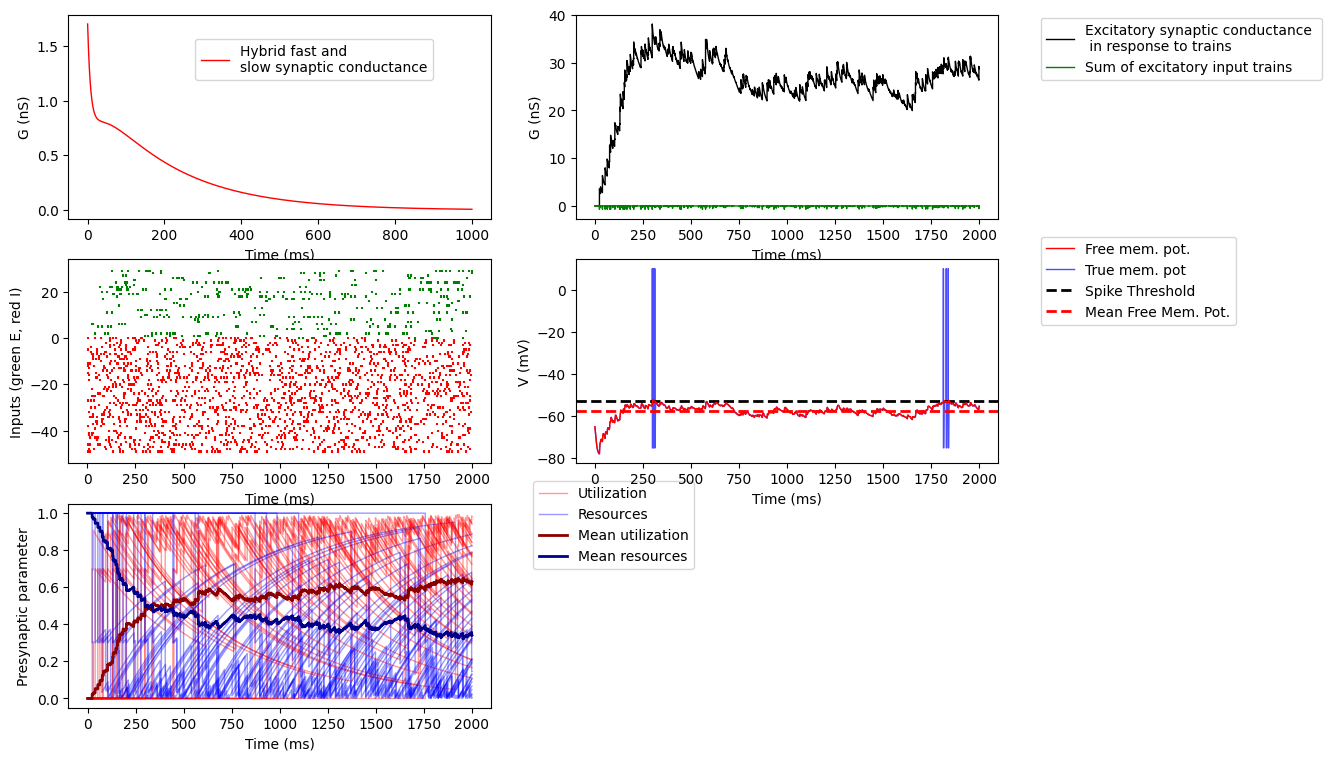

In [36]:
# Get default parameters
pars = default_pars(T=2000.)

# Add parameters
# presynaptic
pars['U0']     = .7         # synaptic release probability at rest
pars['tau_d']  = 500         # synaptic depression time constant of x [ms]
pars['tau_f']  = 500         # synaptic facilitation time constant of u [ms]
pars['STP'] = True         # Switch plasticity on/off here 

# excitatory
pars['gE_bar'] = 3    # [nS] was 2.4   1 receptor is 25 pS
pars['VE'] = 0.         # [mV] excitatory reversal potential
pars['taus_syn_E'] = [8., 40., 200.]  # [ms]
pars['amps_syn_E'] = [1, -.5, 1.2] # unitless - fast decay, slow rise and slow decay
#pars['amps_syn_E'] = [1, 0, 0] # unitless - single fast decay
#pars['amps_syn_E'] = [.5, 0, .5] # unitless - fast decay and slow decay

# inhibitory
pars['gI_bar'] = .6      # [nS]
pars['VI'] = -80.       # [mV] inhibitory reversal potential
pars['tau_syn_I'] = 100.  # [ms]

pars['N_I'] = 50         # Number of inhibitory synapses
pars['N_E'] = 30         # Number of excitatory synapses
pars['r_I'] = 20         # Rate of inhibitory input [Hz]
pars['r_E'] = 10         # Number of excitatory input [Hz]

# Generate presynaptic spike trains
#pre_spike_train_ex = Poisson_generator(pars, pars['r_E'], n=pars['N_E'])
pre_spike_train_ex = Burst_trains(pars, pars['r_E'], n=pars['N_E'])
pre_spike_train_in = Poisson_generator(pars, pars['r_I'], n=pars['N_I'])



# Simulate conductance-based LIF model with spike train matrices
# no injected current
v, rec_spikes, gE, gI = run_LIF_cond(pars, 0, pre_spike_train_ex,
                                     pre_spike_train_in)

# Show spikes more clearly by setting voltage high
dt, range_t = pars['dt'], pars['range_t']
if rec_spikes.size:
  sp_num = (rec_spikes / dt).astype(int) - 1
  v[sp_num] = 10   # draw nicer spikes


# Temporarily remove the threshold 
original_V_th = pars['V_th'] 
pars['V_th'] = 1e3

# Calculate FMP
v_fmp, _, _, _ = run_LIF_cond(pars, 0, pre_spike_train_ex, pre_spike_train_in, first_run=False)

#reset to original threshold for display
pars['V_th'] = original_V_th

# train inputs as a separate graph
my_illus_trains(pars, pre_spike_train_ex, pre_spike_train_in)

#with plt.xkcd():
my_illus_LIFSYN(pars, v_fmp, v)

plt.show()
